In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# bs_e3 = pd.read_csv('10e3/BS_E_e3')
# bs_e4 = pd.read_csv('10e4/BS_E_e4')
# bs_e5 = pd.read_csv('10e5/BS_E_e5')

bs_e3 = pd.read_csv('10e3/BS_E_e3', sep='\t|\s+', engine='python', skiprows=2, header=None)
bs_e3.columns = ['Energy (keV)', 'Hits (Normalized)']

bs_e4 = pd.read_csv('10e4/BS_E_e4', sep='\t|\s+', engine='python', skiprows=2, header=None)
bs_e4.columns = ['Energy (keV)', 'Hits (Normalized)']

bs_e5 = pd.read_csv('10e5/BS_E_e5', sep='\t|\s+', engine='python', skiprows=2, header=None)
bs_e5.columns = ['Energy (keV)', 'Hits (Normalized)']

print(bs_e3.shape)

(300, 2)


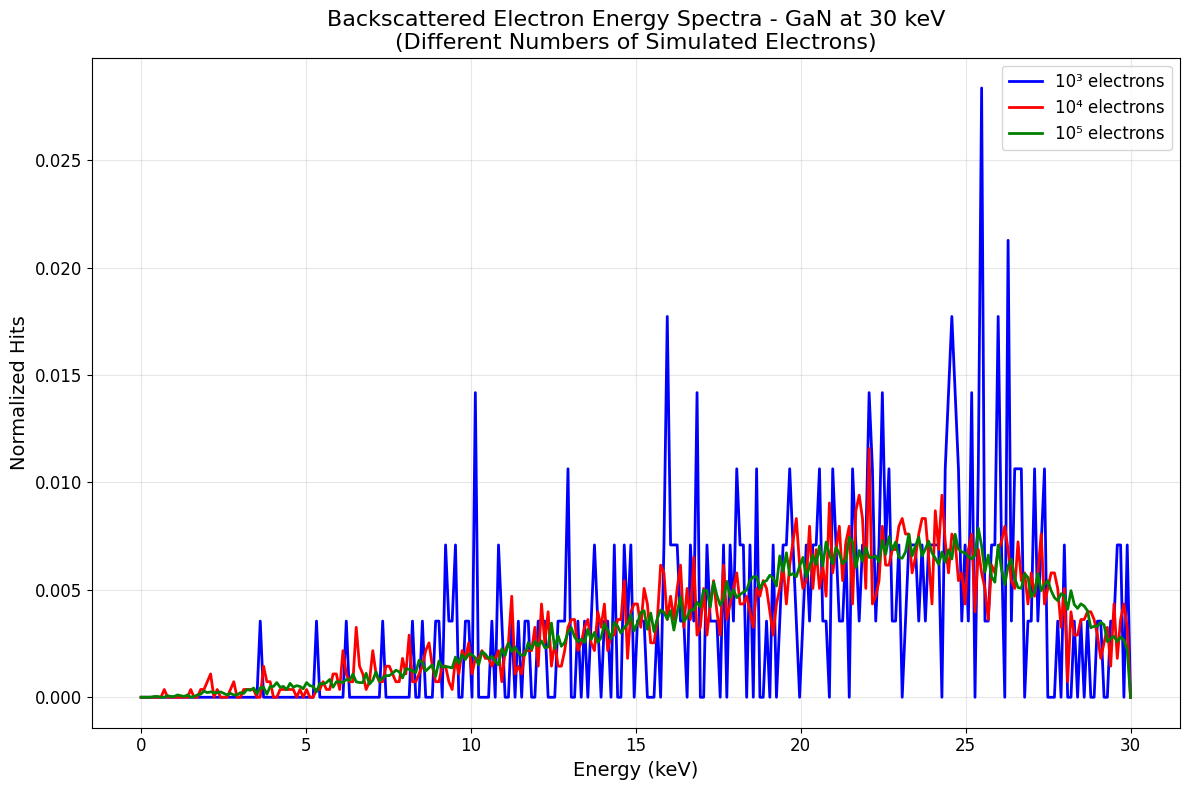

In [26]:
# Create the plot for all three spectra
plt.figure(figsize=(12, 8))

# Plot all three datasets with different styles for clarity
plt.plot(bs_e3['Energy (keV)'], bs_e3['Hits (Normalized)'], 
         label='10³ electrons', linewidth=2, color='blue')
plt.plot(bs_e4['Energy (keV)'], bs_e4['Hits (Normalized)'], 
         label='10⁴ electrons', linewidth=2, color='red')
plt.plot(bs_e5['Energy (keV)'], bs_e5['Hits (Normalized)'], 
         label='10⁵ electrons', linewidth=2, color='green')

# Professional formatting (important for your assignment!)
plt.xlabel('Energy (keV)', fontsize=14)
plt.ylabel('Normalized Hits', fontsize=14)
plt.title('Backscattered Electron Energy Spectra - GaN at 30 keV\n(Different Numbers of Simulated Electrons)', 
          fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', which='major', labelsize=12)

# Make it look professional
plt.tight_layout()
plt.show()

# Optional: Save the figure
# plt.savefig('BS_Energy_Spectra_Comparison.png', dpi=300, bbox_inches='tight')

Why the 3 spectra are not identical:

Statistical noise: With fewer electrons (10³), you get more statistical fluctuations
Monte Carlo uncertainty: Each simulation uses random sampling
Smoothness: Higher electron counts (10⁵) give smoother, more reliable curves
Peak definition: Low statistics may miss or poorly define spectral features

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy import integrate

# Prepare the data
x_data = bs_e5['Energy (keV)'].values
y_data = bs_e5['Hits (Normalized)'].values

# Define all our fitting functions
def exponential_func(x, a, b, c):
    """Exponential decay: a * exp(-b*x) + c"""
    return a * np.exp(-b * x) + c

def gaussian_func(x, a, b, c, d):
    """Gaussian: a * exp(-((x-b)/c)^2) + d"""
    return a * np.exp(-((x - b) / c)**2) + d

def power_law_func(x, a, b, c):
    """Power law: a * (x+1)^(-b) + c"""
    return a * (x + 1)**(-b) + c

def linear_func(x, a, b):
    """Linear: a*x + b"""
    return a * x + b

def quadratic_func(x, a, b, c):
    """Quadratic: a*x^2 + b*x + c"""
    return a * x**2 + b * x + c

# Store all functions and their names
functions = {
    'Exponential': exponential_func,
    'Gaussian': gaussian_func, 
    'Power Law': power_law_func,
    'Linear': linear_func,
    'Quadratic': quadratic_func
}

# Try fitting each function
fit_results = {}
fit_errors = {}

print("Attempting to fit all functions...")
print("="*50)

for name, func in functions.items():
    try:
        # Different initial guesses for different functions
        if name == 'Exponential':
            p0 = [0.01, 0.1, 0.001]
        elif name == 'Gaussian':
            p0 = [0.01, 15, 5, 0.001]  # peak at ~15 keV
        elif name == 'Power Law':
            p0 = [0.1, 1, 0.001]
        elif name == 'Linear':
            p0 = [0.0001, 0.001]
        elif name == 'Quadratic':
            p0 = [1e-6, 0.0001, 0.001]
            
        # Perform the fit
        popt, pcov = curve_fit(func, x_data, y_data, p0=p0, maxfev=5000)
        
        # Calculate R-squared
        y_pred = func(x_data, *popt)
        ss_res = np.sum((y_data - y_pred) ** 2)
        ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)
        r_squared = 1 - (ss_res / ss_tot)
        
        # Store results
        fit_results[name] = {'params': popt, 'r_squared': r_squared, 'y_pred': y_pred}
        
        print(f"{name:12}: R² = {r_squared:.6f} ✓")
        
    except Exception as e:
        print(f"{name:12}: Failed - {str(e)[:50]}...")
        fit_errors[name] = str(e)

print("="*50)

Attempting to fit all functions...
Exponential : R² = 0.753513 ✓
Gaussian    : R² = 0.955705 ✓
Power Law   : R² = 0.677323 ✓
Linear      : R² = 0.707834 ✓
Quadratic   : R² = 0.782054 ✓


/tmp/ipykernel_9853/813200142.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  raw_integral = np.trapz(y_data, x_data)
/tmp/ipykernel_9853/813200142.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  fit_integral = np.trapz(y_fit, x_data)


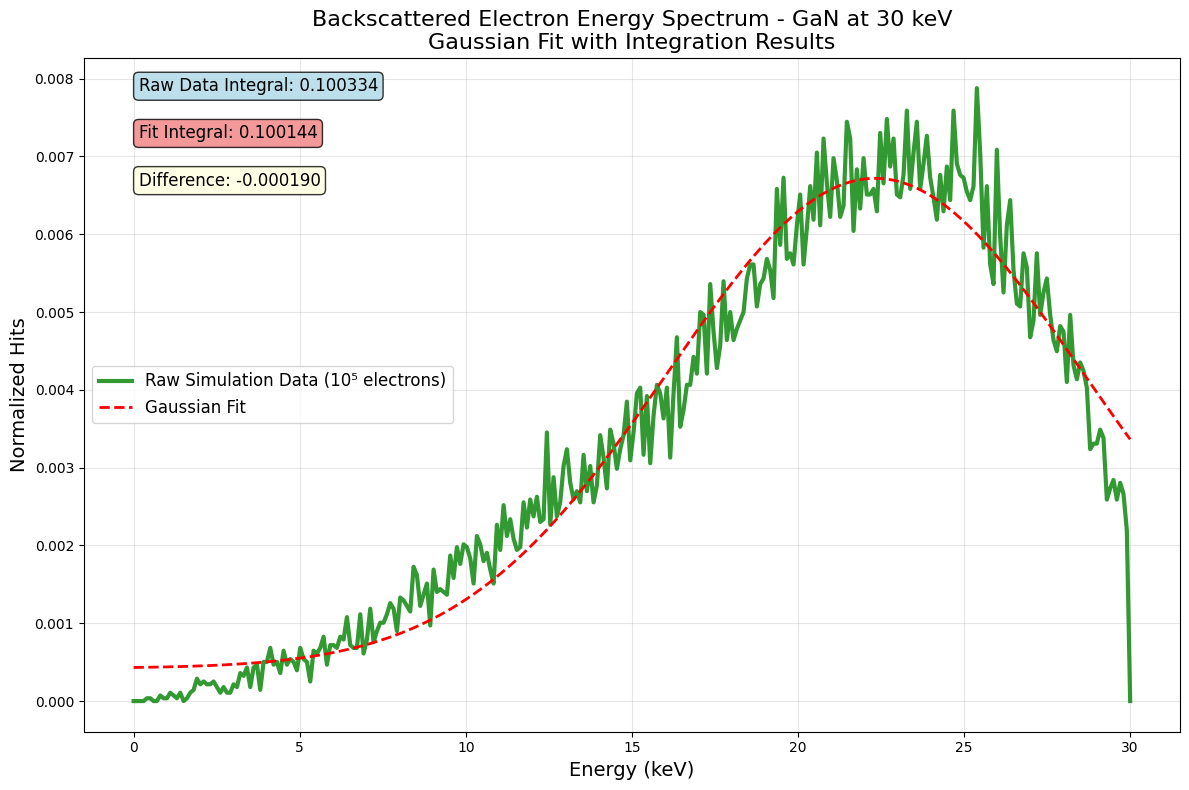

Physical Meaning of Integrals:
The integrals represent the TOTAL BACKSCATTERED ELECTRON YIELD
- Area under the energy spectrum curve
- Fraction of incident electrons that are backscattered
- Should be conserved between raw data and good fit
- Meaningful because it's a fundamental physical quantity


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy import integrate

# Use the e5 data
x_data = bs_e5['Energy (keV)'].values
y_data = bs_e5['Hits (Normalized)'].values

# Define our chosen fitting function (Gaussian)
def gaussian_func(x, a, b, c, d):
    """Gaussian: a * exp(-((x-b)/c)^2) + d"""
    return a * np.exp(-((x - b) / c)**2) + d

# Fit the function
popt, pcov = curve_fit(gaussian_func, x_data, y_data, 
                       p0=[0.01, 15, 5, 0.001], maxfev=5000)

# Generate fitted curve
y_fit = gaussian_func(x_data, *popt)

# Calculate integrals
raw_integral = np.trapz(y_data, x_data)
fit_integral = np.trapz(y_fit, x_data)

# Create the plot as requested
plt.figure(figsize=(12, 8))

# Plot raw data and fit
plt.plot(x_data, y_data, 'g-', linewidth=3, label='Raw Simulation Data (10⁵ electrons)', alpha=0.8)
plt.plot(x_data, y_fit, 'r--', linewidth=2, label='Gaussian Fit')

# Add integral values as text on the graph
plt.text(0.05, 0.95, f'Raw Data Integral: {raw_integral:.6f}', 
         transform=plt.gca().transAxes, fontsize=12, 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.8))
plt.text(0.05, 0.88, f'Fit Integral: {fit_integral:.6f}', 
         transform=plt.gca().transAxes, fontsize=12,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral", alpha=0.8))
plt.text(0.05, 0.81, f'Difference: {fit_integral - raw_integral:+.6f}', 
         transform=plt.gca().transAxes, fontsize=12,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

# Formatting
plt.xlabel('Energy (keV)', fontsize=14)
plt.ylabel('Normalized Hits', fontsize=14)
plt.title('Backscattered Electron Energy Spectrum - GaN at 30 keV\nGaussian Fit with Integration Results', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Physical Meaning of Integrals:")
print("="*40)
print("The integrals represent the TOTAL BACKSCATTERED ELECTRON YIELD")
print("- Area under the energy spectrum curve")
print("- Fraction of incident electrons that are backscattered")
print("- Should be conserved between raw data and good fit")
print("- Meaningful because it's a fundamental physical quantity")

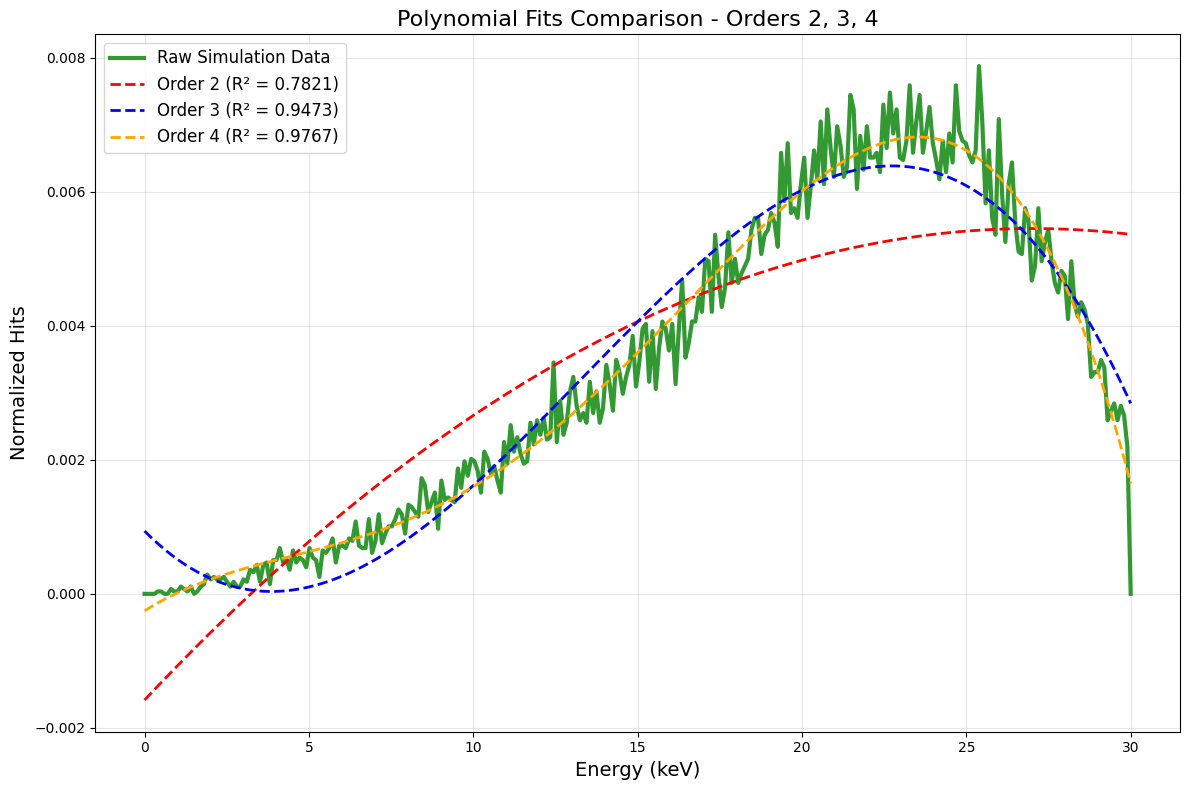

ASSIGNMENT ANSWERS:
Which polynomial order gives the best fit?
Order 4 with R² = 0.976738

Key BENEFIT of polynomial fits:
- Mathematical simplicity and ease of implementation

Key SHORTCOMING of polynomial fits:
- No physical meaning - purely mathematical curve fitting
- Can oscillate wildly outside the data range


In [37]:
# Polynomial fits of order 2, 3, and 4 ONLY
polynomial_results = {}

for degree in [2, 3, 4]:
    # Fit polynomial
    coeffs = np.polyfit(x_data, y_data, degree)
    poly_func = np.poly1d(coeffs)
    y_pred = poly_func(x_data)
    
    # Calculate R-squared
    ss_res = np.sum((y_data - y_pred) ** 2)
    ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
    
    polynomial_results[degree] = {
        'y_pred': y_pred,
        'r_squared': r_squared,
        'coeffs': coeffs
    }

# Plot polynomial comparison
plt.figure(figsize=(12, 8))

# Raw data
plt.plot(x_data, y_data, 'g-', linewidth=3, label='Raw Simulation Data', alpha=0.8)

# Polynomial fits
colors = ['red', 'blue', 'orange']
for i, (degree, result) in enumerate(polynomial_results.items()):
    plt.plot(x_data, result['y_pred'], '--', linewidth=2, 
             color=colors[i], label=f'Order {degree} (R² = {result["r_squared"]:.4f})')

plt.xlabel('Energy (keV)', fontsize=14)
plt.ylabel('Normalized Hits', fontsize=14)
plt.title('Polynomial Fits Comparison - Orders 2, 3, 4', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Answer the assignment questions
print("ASSIGNMENT ANSWERS:")
print("="*40)
print("Which polynomial order gives the best fit?")
best_order = max(polynomial_results.keys(), key=lambda k: polynomial_results[k]['r_squared'])
print(f"Order {best_order} with R² = {polynomial_results[best_order]['r_squared']:.6f}")

print(f"\nKey BENEFIT of polynomial fits:")
print("- Mathematical simplicity and ease of implementation")

print(f"\nKey SHORTCOMING of polynomial fits:")
print("- No physical meaning - purely mathematical curve fitting")
print("- Can oscillate wildly outside the data range")

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Load radial distribution data (SR_BE files)
sr_e3 = pd.read_csv('10e3/SR_BE_e3', sep='\t|\s+', engine='python', skiprows=2, header=None)
sr_e3.columns = ['Radius (nm)', 'Hits (Normalized) / nm²']

sr_e4 = pd.read_csv('10e4/SR_BE_e4', sep='\t|\s+', engine='python', skiprows=2, header=None)
sr_e4.columns = ['Radius (nm)', 'Hits (Normalized) / nm²']

sr_e5 = pd.read_csv('10e5/SR_BE_e5', sep='\t|\s+', engine='python', skiprows=2, header=None)
sr_e5.columns = ['Radius (nm)', 'Hits (Normalized) / nm²']

# Check the data
print("Radial distribution data loaded successfully!")
for name, df in [('10³', sr_e3), ('10⁴', sr_e4), ('10⁵', sr_e5)]:
    print(f"\n{name} electrons:")
    print(f"Shape: {df.shape}")
    print(f"Radius range: {df['Radius (nm)'].min():.1f} - {df['Radius (nm)'].max():.1f} nm")
    print(f"Max hits: {df['Hits (Normalized) / nm²'].max():.2e}")
    print(f"Value at 0 nm: {df['Hits (Normalized) / nm²'].iloc[0]:.2e}")

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xb2 in position 56: invalid start byte